#Setup


In [4]:
# Import the necessary modules 
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from gensim.parsing.preprocessing import STOPWORDS

root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
reports_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'reports')
figures_dir = os.path.join(reports_dir, 'figures')
tables_dir = os.path.join(reports_dir, 'tables')
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
print(f"Figures will be saved to: {figures_dir}")
print(f"Tables will be saved to: {tables_dir}")


Figures will be saved to: e:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\notebooks\01_eda\reports\figures
Tables will be saved to: e:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\notebooks\01_eda\reports\tables


In [5]:
# Core installs
# !pip install -q pandas numpy scikit-learn matplotlib seaborn nltk tqdm
# !pip install -q sentence-transformers umap-learn hdbscan
# !pip install -q bertopic
# !pip install -q wordcloud
# !pip install -q kagglehub

# import os
# # Setup directories for saving outputs
# root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
# reports_dir = os.path.join(root_path, 'reports')
# figures_dir = os.path.join(reports_dir, 'figures')
# tables_dir = os.path.join(reports_dir, 'tables')
# os.makedirs(figures_dir, exist_ok=True)
# os.makedirs(tables_dir, exist_ok=True)
# print(f"Figures will be saved to: {figures_dir}")
# print(f"Tables will be saved to: {tables_dir}")

In [6]:
#### updated the code to access the file from local - THIRUVEL 
# df = pd.read_csv("data/raw/customer_support_tickets.csv", encoding='utf-8')
# print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
# df.head()

### actual code
# import kagglehub
# # Download dataset
# path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
# print("Path to dataset files:", path)

In [7]:
#### Read data from /data/raw/customer_support_tickets.csv - ZHAOQI
current_dir = os.getcwd()

if "notebooks" in current_dir:
    root_path = current_dir.split("notebooks")[0] 
else:
    root_path = current_dir

csv_path = os.path.join(root_path, "data", "raw", "customer_support_tickets.csv")

print(f"{csv_path}")

df = pd.read_csv(csv_path, encoding='utf-8')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

e:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\data\raw\customer_support_tickets.csv
Dataset: 8469 rows, 17 columns


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [8]:
# import pandas as pd
# import os
# #### updated the code to access the file from local - THIRUVEL 
# df = pd.read_csv(os.path.join(root_path, "data/raw/customer_support_tickets.csv"), encoding='utf-8')
# print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
# df.head()

# Data Overview

In [9]:
# Check basic info and shape of the dataset
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (8469, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 n

In [10]:
# Display the first 5 rows
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [11]:
# List columns and their data types
df.dtypes

Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object

In [12]:
# Check for missing values
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [13]:
# Descriptive statistics for numeric columns
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [14]:
# Look at unique values for categorical/text columns
for col in df.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(df[col].value_counts().head(10))
    print("-" * 40)

Column: Customer Name
Customer Name
Michael Garcia       5
James Smith          5
Christopher Jones    4
Steven Johnson       4
Daniel Williams      4
David Smith          4
Joseph Brown         4
Jennifer Smith       4
Rebecca Smith        4
Michael White        4
Name: count, dtype: int64
----------------------------------------
Column: Customer Email
Customer Email
asmith@example.com              4
bsmith@example.com              4
hsmith@example.org              3
michael41@example.net           3
asmith@example.org              3
drodriguez@example.com          3
elizabethjenkins@example.com    3
rodriguezeric@example.net       3
jdavis@example.org              2
michaelmiller@example.org       2
Name: count, dtype: int64
----------------------------------------
Column: Customer Gender
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64
----------------------------------------
Column: Product Purchased
Product Purchased
Canon EOS              240

Observations
Customer Info

Dataset includes customer names, emails, and gender.
Gender distribution is fairly balanced: Male (2896), Female (2887), Other (2686).
Products

Top products purchased include Canon EOS, GoPro Hero, Nest Thermostat, Amazon Echo, and Philips Hue Lights.
Product purchases are concentrated among the top 10 products.
Tickets

Ticket types are varied: Refund requests (1752), Technical issues (1747), Cancellation requests (1695), Product inquiries (1641), Billing inquiries (1634).
Ticket subjects reflect common issues like refunds, software bugs, and delivery problems.
Ticket descriptions contain repeated templates referencing products and errors.
Status & Resolution

Ticket statuses: Pending Customer Response (2881), Open (2819), Closed (2769).
Resolutions are unique and often nonsensical in text; may require preprocessing for text analysis.
Priority & Channel

Ticket priority is distributed across Medium, Critical, High, Low.
Most tickets come through Email, Phone, Social media, and Chat almost evenly.
Timing

First Response Time and Time to Resolution show some recurring timestamps, suggesting simulated or anonymized data.

# Text Construction

In [15]:
# Combine Ticket Subject and Ticket Description into a single text column
df['text'] = df['Ticket Subject'].fillna('') + " " + df['Ticket Description'].fillna('')
df[['Ticket Subject', 'Ticket Description', 'text']].head()

,Ticket Subject,Ticket Description,text
0,Product setup,I'm having an issue with the {product_purchase...,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility I'm having an issue w...
2,Network problem,I'm facing a problem with my {product_purchase...,Network problem I'm facing a problem with my {...
3,Account access,I'm having an issue with the {product_purchase...,Account access I'm having an issue with the {p...
4,Data loss,I'm having an issue with the {product_purchase...,Data loss I'm having an issue with the {produc...


Saved figure: eda_ukhash_fig_10.png


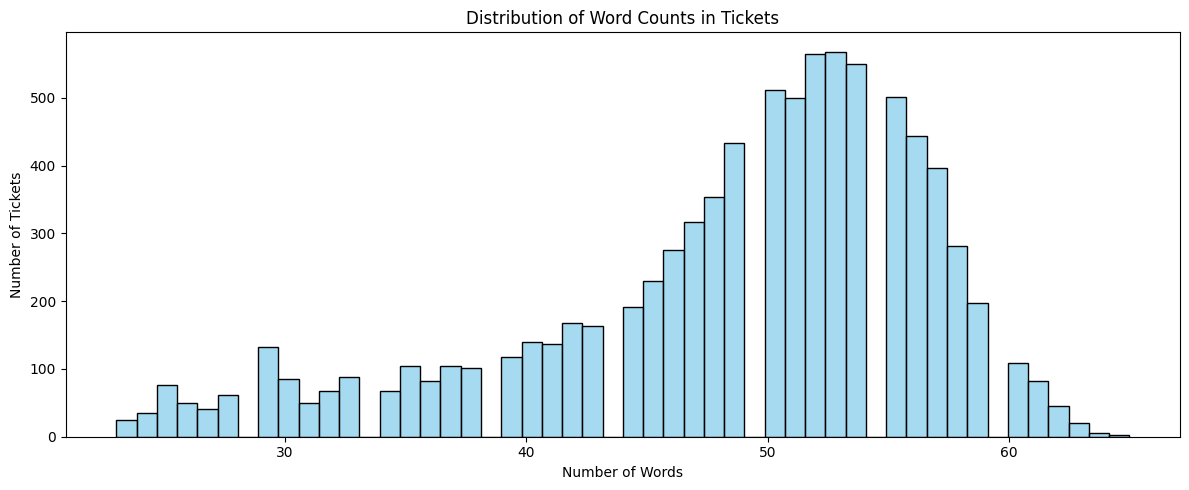

Average text length (chars): 306.54681780611645
Average word count: 48.46735151729838


In [16]:
import os
# Number of characters and words in the combined text
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.histplot(df['word_count'], bins=50, color='skyblue')
plt.title("Distribution of Word Counts in Tickets")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_wordcount_distribution.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_10.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_10.png")

plt.show()

print("Average text length (chars):", df['text_length'].mean())
print("Average word count:", df['word_count'].mean())

In [17]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\{.*?\}', '', text)  # remove placeholders like {product_purchased}, {error_message}
    text = re.sub(r'[^a-z0-9\s]', '', text)  # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Product setup I'm having an issue with the {pr...,product setup im having an issue with the plea...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility im having an issue wi...
2,Network problem I'm facing a problem with my {...,network problem im facing a problem with my th...
3,Account access I'm having an issue with the {p...,account access im having an issue with the ple...
4,Data loss I'm having an issue with the {produc...,data loss im having an issue with the please a...


Saved figure: eda_ukhash_fig_12.png


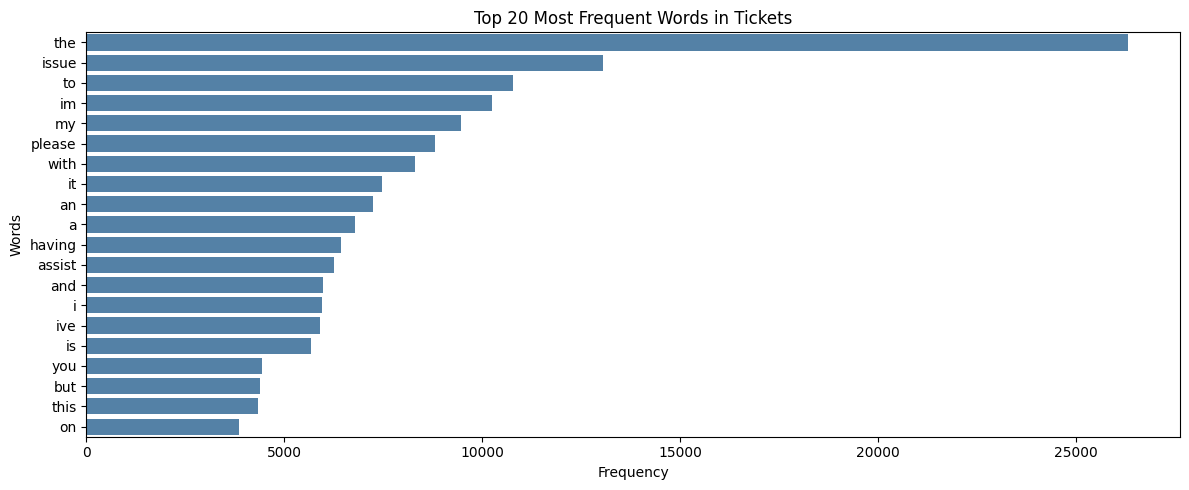

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
# Get word frequency first
from collections import Counter
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)

# Now plot
words, counts = zip(*top_words)
plt.figure(figsize=(12,5))
sns.barplot(x=list(counts), y=list(words), color='steelblue')
plt.title("Top 20 Most Frequent Words in Tickets")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_top20_words.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_12.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_12.png")

plt.show()

Text Construction Summary
Combined Ticket Subject + Ticket Description into text.
Cleaned text: lowercase, removed placeholders and special characters.
Avg length: ~307 chars, ~48 words.
Text is ready for NLP and clustering.

#Exploratory Data Analysis (EDA)

Ticket Type Counts:
 Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
Saved figure: eda_ukhash_fig_13.png


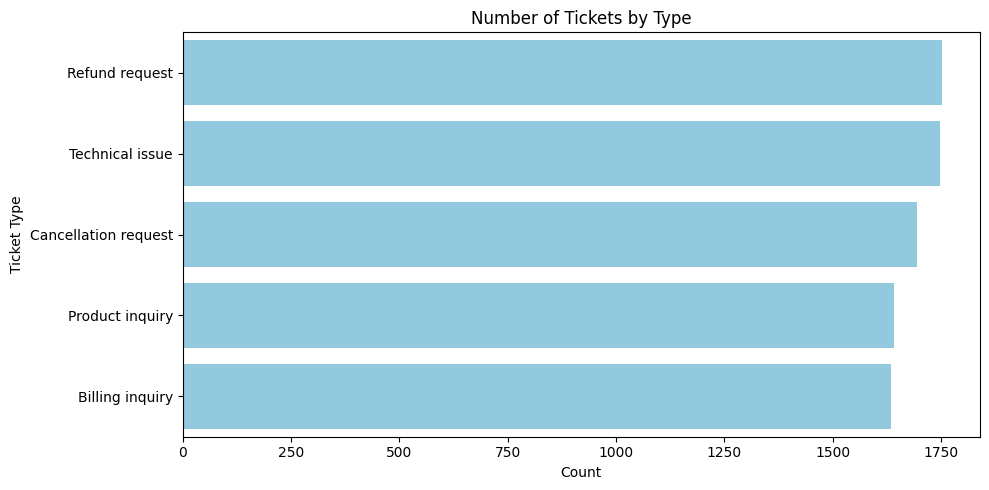

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
ticket_type_counts = df['Ticket Type'].value_counts()
print("Ticket Type Counts:\n", ticket_type_counts)

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y='Ticket Type',
    order=ticket_type_counts.index,
    color='skyblue'
)
plt.title("Number of Tickets by Type")
plt.xlabel("Count")
plt.ylabel("Ticket Type")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_tickets_by_type.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_13.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_13.png")

plt.show()

Ticket Priority Counts:
 Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64
Saved figure: eda_ukhash_fig_14.png


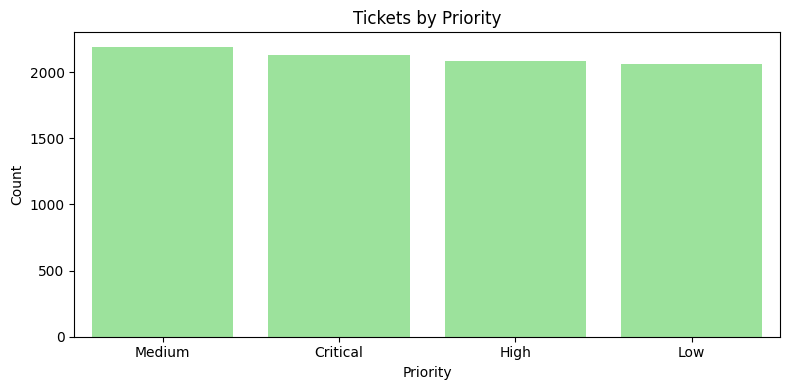

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
priority_counts = df['Ticket Priority'].value_counts()
print("Ticket Priority Counts:\n", priority_counts)

plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x='Ticket Priority',
    order=priority_counts.index,
    color='lightgreen'
)
plt.title("Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_tickets_by_priority.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_14.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_14.png")

plt.show()

Ticket Channel Counts:
 Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64
Saved figure: eda_ukhash_fig_15.png


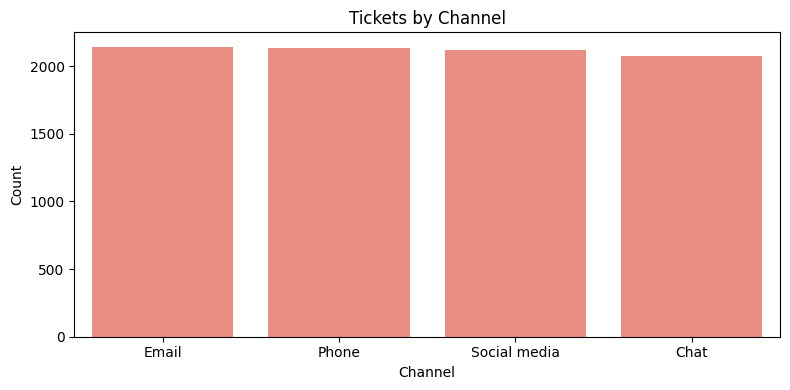

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
channel_counts = df['Ticket Channel'].value_counts()
print("Ticket Channel Counts:\n", channel_counts)

plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x='Ticket Channel',
    order=channel_counts.index,
    color='salmon'
)
plt.title("Tickets by Channel")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_tickets_by_channel.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_15.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_15.png")

plt.show()

Word Count Stats:
Min: 23
Max: 65
Mean: 48.47
Median: 51.0
Saved figure: eda_ukhash_fig_16.png


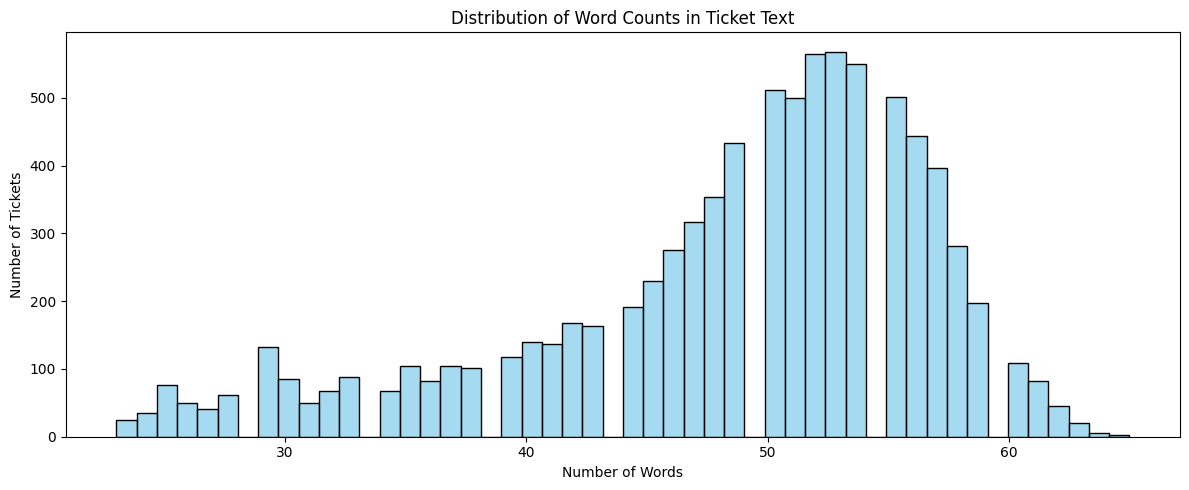

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
print("Word Count Stats:")
print("Min:", df['word_count'].min())
print("Max:", df['word_count'].max())
print("Mean:", round(df['word_count'].mean(),2))
print("Median:", df['word_count'].median())

plt.figure(figsize=(12,5))
sns.histplot(df['word_count'], bins=50, color='skyblue')
plt.title("Distribution of Word Counts in Ticket Text")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_wordcount_distribution2.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_16.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_16.png")

plt.show()

Top 20 Words:
 [('the', 26320), ('issue', 13067), ('to', 10780), ('im', 10252), ('my', 9464), ('please', 8809), ('with', 8309), ('it', 7462), ('an', 7250), ('a', 6786), ('having', 6429), ('assist', 6250), ('and', 5974), ('i', 5948), ('ive', 5897), ('is', 5668), ('you', 4441), ('but', 4384), ('this', 4346), ('on', 3865)]
Saved figure: eda_ukhash_fig_17.png


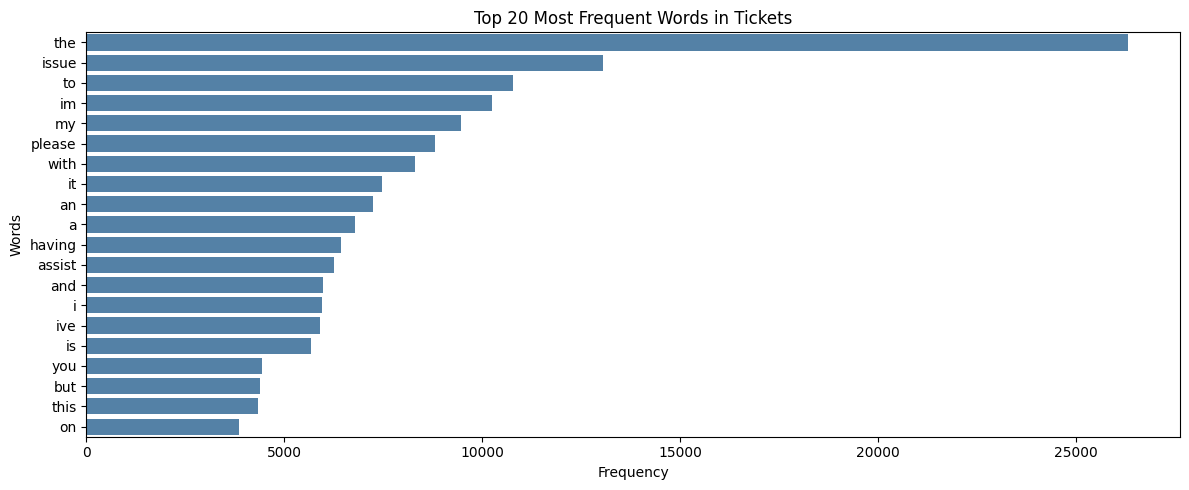

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)

print("Top 20 Words:\n", top_words)

words, counts = zip(*top_words)
plt.figure(figsize=(12,5))
sns.barplot(x=list(counts), y=list(words), color='steelblue')
plt.title("Top 20 Most Frequent Words in Tickets")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_top20_words2.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_17.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_17.png")

plt.show()

Saved figure: eda_ukhash_fig_18.png


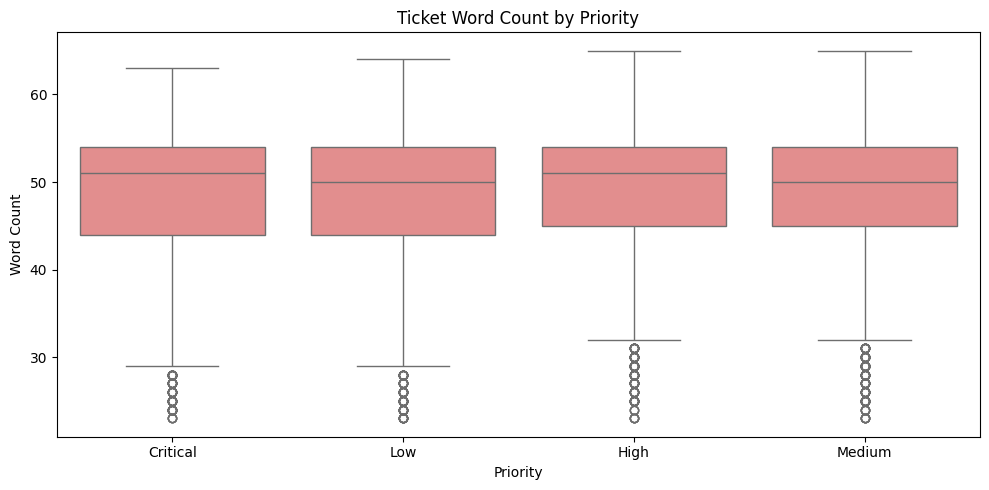

Average Word Count by Priority:
 Ticket Priority
Critical    48.40
High        48.84
Low         48.15
Medium      48.48
Name: word_count, dtype: float64


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Ticket Priority', y='word_count', color='lightcoral')
plt.title("Ticket Word Count by Priority")
plt.xlabel("Priority")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_wordcount_by_priority.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_18.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_18.png")

plt.show()

avg_word_by_priority = df.groupby('Ticket Priority')['word_count'].mean()
print("Average Word Count by Priority:\n", round(avg_word_by_priority,2))

Ticket Type vs Channel Counts:
 Ticket Channel        Chat  Email  Phone  Social media
Ticket Type                                           
Billing inquiry        398    405    434           397
Cancellation request   408    448    426           413
Product inquiry        388    427    424           402
Refund request         426    455    427           444
Technical issue        453    408    421           465
Saved figure: eda_ukhash_fig_19.png


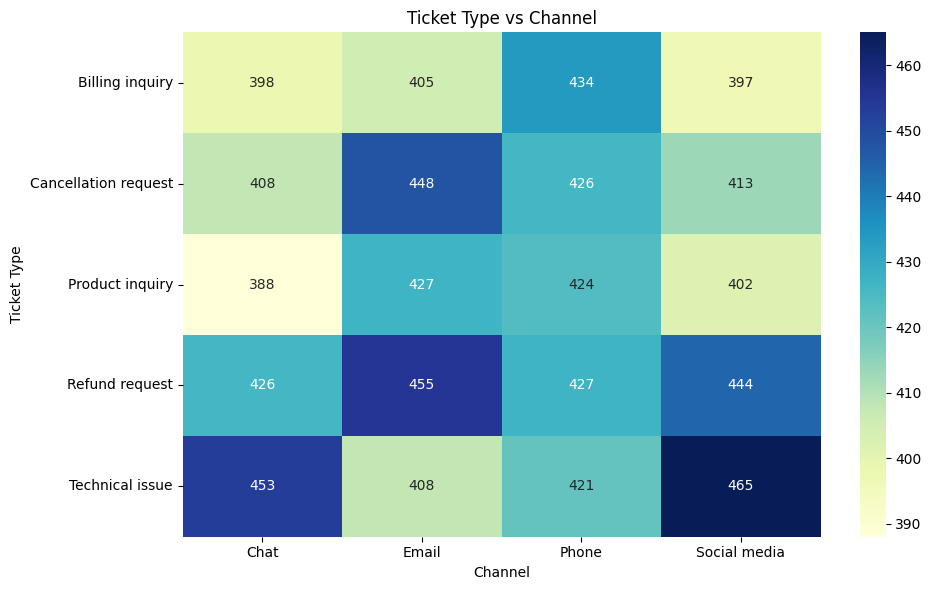

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
channel_type = pd.crosstab(df['Ticket Type'], df['Ticket Channel'])
print("Ticket Type vs Channel Counts:\n", channel_type)

plt.figure(figsize=(10,6))
sns.heatmap(channel_type, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Ticket Type vs Channel")
plt.xlabel("Channel")
plt.ylabel("Ticket Type")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_tickettype_channel_heatmap.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_ukhash_fig_19.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_ukhash_fig_19.png")

plt.show()

1️⃣ Ticket Type Distribution
Refund requests and Technical issues are the most common ticket types, indicating frequent customer concerns in these areas.




2️⃣ Ticket Priority Distribution
Most tickets are Medium or Critical priority, showing a relatively balanced workload that requires attention across all priority levels.

3️⃣ Ticket Channel Distribution
Tickets are nearly evenly split among Email, Phone, Social Media, and Chat. Customers use multiple channels consistently, highlighting the need for multi-channel support.

4️⃣ Word Count Distribution
Most ticket descriptions are concise, averaging around 48 words, which is sufficient to capture customer issues without being too long.

5️⃣ Frequent Words in Tickets
Common words like issue, please, and assist indicate that customers mainly report problems and request help, revealing recurring patterns in support requests.

6️⃣ Average Word Count by Priority
Critical and High priority tickets are slightly longer, suggesting more complex issues that require detailed descriptions.

7️⃣ Ticket Type vs Channel
Refund requests and Technical issues show some variation across channels: Refunds are more on Email and Social Media, while Technical issues are more reported via Chat and Social Media. This helps optimize channel-specific staffing and routing

In [26]:
# !git clone https://github.com/fahmi-alshahabi/EMATM0067_2025_TB-2-g43.git
# %cd EMATM0067_2025_TB-2-g43

# # switch to your branch
# !git checkout utkarsh

# # copy your notebook into notebooks folder
# !cp /content/Untitled1.ipynb notebooks/

# # commit and push
# !git add notebooks/Untitled1.ipynb
# !git commit -m "added Untitled1 notebook"
# !git push origin utkarsh